# 04 — Adaptive backtest

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA_DIR = (ROOT / "../data/raw").resolve()
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Research parameters
REBALANCE_FREQUENCY = "ME"
VOLATILITY_WINDOW = 60
ANNUAL_VOLATILITY_TARGET = 0.10
LEVERAGE_CAP = 4.0
LONG_FRACTION = 0.30
SHORT_FRACTION = 0.30
TRANSACTION_COST_BPS = 5.0
MINIMUM_TRAINING_MONTHS = 60
PROBABILITY_THRESHOLD = 0.50
RANDOM_STATE = 42

print("Data directory:", DATA_DIR)

from src.models import probability_exposure
from src.evaluation import summary_statistics


Data directory: C:\Users\vidhi\OneDrive\Desktop\Project lab\Summer\FX_Carry_26_Summer_PL\data\raw


In [2]:
static = pd.read_csv(
    OUTPUT_DIR / "static_carry_returns.csv",
    index_col=0,
    parse_dates=True,
).iloc[:, 0]

dataset = pd.read_parquet(OUTPUT_DIR / "regime_dataset.parquet")
probability = dataset["probability"].dropna()

monthly_static = (1.0 + static.fillna(0.0)).resample("ME").prod() - 1.0

binary_exposure = (probability >= PROBABILITY_THRESHOLD).astype(float)
scaled_exposure = probability_exposure(probability)

comparison = pd.DataFrame(
    {
        "static": monthly_static,
        "binary_filter": monthly_static * binary_exposure.shift(1),
        "probability_scaled": monthly_static * scaled_exposure.shift(1),
    }
).dropna(how="all")

statistics = pd.DataFrame(
    {
        column: summary_statistics(
            comparison[column],
            periods_per_year=12,
        )
        for column in comparison
    }
).T

display(statistics)

comparison.to_csv(
    OUTPUT_DIR / "adaptive_strategy_returns_monthly.csv"
)
statistics.to_csv(
    OUTPUT_DIR / "adaptive_strategy_summary.csv"
)


,annual_return,annual_volatility,sharpe,sortino,maximum_drawdown,calmar,hit_rate,observations
static,-0.059524,0.084181,-0.707092,-0.775061,-0.719472,-0.082732,0.384615,234.0
binary_filter,-0.033291,0.059750,-0.557171,-0.466014,-0.434287,-0.076656,0.190751,173.0
probability_scaled,-0.033010,0.059056,-0.558963,-0.472878,-0.419147,-0.078756,0.225434,173.0


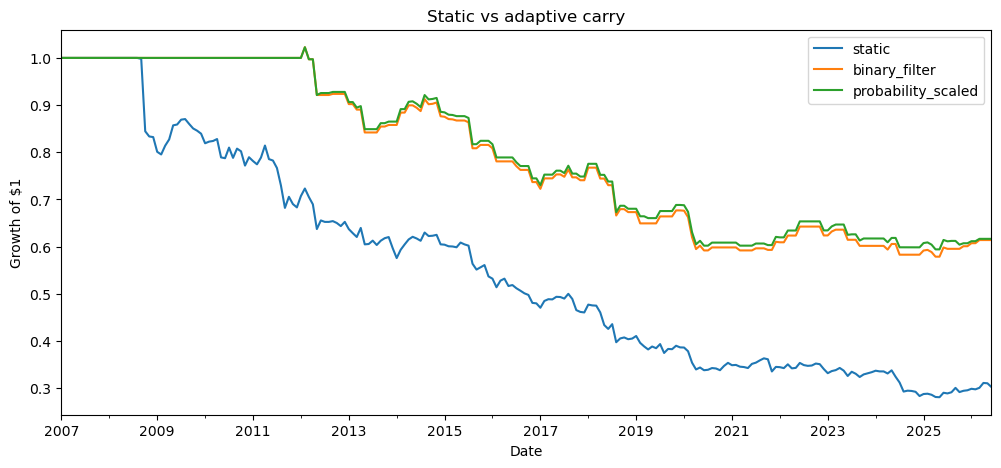

In [9]:
comp = comparison.copy()

(1 + comp.fillna(0)).cumprod().plot(
    figsize=(12, 5),
    title="Static vs adaptive carry"
)

plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.show()

The obejctive here is reduce the losses rather than focusing on maximising profits.

In [12]:
regime = pd.cut(
    dataset["probability"],
    [-np.inf, 0.4, 0.6, np.inf],
    labels=["risk_off", "neutral", "risk_on"]
)